# 3×3 Rydberg quench 当前可用后端 benchmark

这个 notebook 用同一套 3×3 `1r` 方格晶格和同一条失谐扫描 protocol。
在 `1r` 能级结构下，每个格点有两能级：`|1⟩`（基态）和 `|r⟩`（Rydberg）。对本 notebook 的 3×3 方格（9 格点、最近邻 VdW），时间依赖 Hamiltonian 为：

$$
H(t) = \sum_{i=0}^{8} \left[ \frac{\Omega(t)}{2}\,\sigma^x_i - \Delta_i(t)\, n_i^r \right] + \sum_{\langle i,j\rangle} V_{ij}\, n_i^r n_j^r
$$

其中：
- $\sigma^x_i = |r\rangle\langle 1|_i + |1\rangle\langle r|_i$
- $n_i^r = |r\rangle\langle r|_i$（Rydberg 占据算符）
- $\Delta_i(t) = \Delta(t) + \Delta_{\mathrm{addr},i}(t)$；
- $V_{ij} = C_6 / r_{ij}^6$，`mode="nn"` 只保留最近邻，在$r = 6 \mu m, 10 \mu m$时，Rydberg interaction分别是 $2\pi 	imes 18 MHz,2\pi 	imes  0.874 MHz$
- 角频率单位均为 rad/s

除了`backend="exact"`
当前可用的 TN 公开入口只有：
- `backend="mps"`：TeNPy CPU MPS reference；
- `backend="peps"`：YASTN finite PEPS，二维 lattice 主路径；
- `backend="gputn"`：cuTensorNet/CuPy GPU experimental path。


In [5]:
import importlib
import time

import numpy as np
import matplotlib.pyplot as plt
import ryd_gate as rg
import ryd_gate.protocols.sweep as rg_sweep
from ryd_gate import InteractionSpec
from ryd_gate.lattice import make_square_lattice
from ryd_gate.backends.tn_common.compiler import tn_lattice_spec_from_system

这里使用两条不同形状的平滑波形，先增加Rabi/detuning，后减少。
Sweep time不能选择太久，按照300K 下 70S Rydberg decay rate $\Gamma = 1/151.55 (\mu s)^{-1}$.
如果想要控制每个原子的loss rate 在 $0.99$以下，至少需要 $t = -\ln(0.99)\times 151.55 \mu s \approx 1.523 \mu s$.


- Rabi 用 smooth flat-top：先用 smootherstep 平滑打开，保持平台，再平滑关闭。取 $h(u)=10u^3-15u^4+6u^5$。
- 并令平台边缘宽度为 $\tau_r=0.09T$。这样在两次共振穿越附近，$\Omega(t)/2$ 已经处在平台上，avoided crossing 的 gap 足够大，第二次扫回时更容易把多体态带回基态。
- 这个量级是否可以由 AOM + analog RF driver/AWG 做到？

Detuning 用余弦往返：
$$
\Delta(t)=\Delta_{\rm mid}-\Delta_{\rm amp}\cos(2\pi t/T),
$$
其中 $\Delta_{\rm mid}=(\Delta_{\rm start}+\Delta_{\rm end})/2$，$\Delta_{\rm amp}=(\Delta_{\rm end}-\Delta_{\rm start})/2$。它保持 $-10\to +10\to -10\,\mathrm{MHz}$ 的取值范围，并且端点斜率为零。实验上 detuning 波形通常通过 chirp AOM RF frequency、EOM/PLL，或直接调激光频率实现；AWG 应输出连续相位 $\phi(t)=2\pi\int f_{\rm RF}(t)dt$，而不是只逐点跳频。

AOM 用作 Rabi 光强调制时，控制链路近似为
$$
V_{\mathrm{AWG}}(t)\rightarrow P_{\mathrm{RF}}(t)\rightarrow P_{\mathrm{opt}}(t)\rightarrow \Omega(t).
$$
如果想要 $\Omega(t)\propto b(t)$，通常光功率目标应接近 $P_{\mathrm{opt}}(t)\propto b(t)^2$。因此代码里的 `omega_half_t` 是目标 Rabi envelope；实际 AWG 电压需要根据测得的 AOM transfer function 反推。

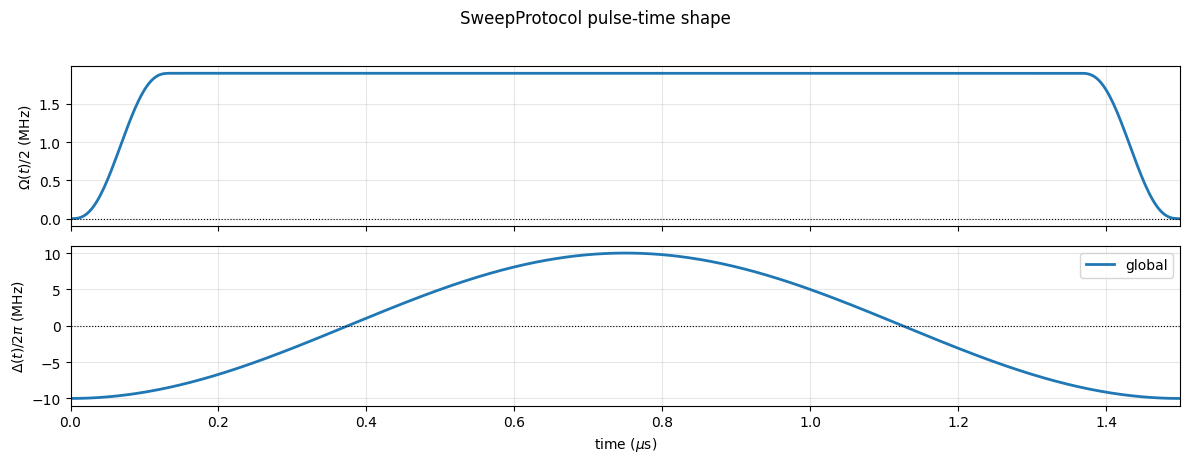

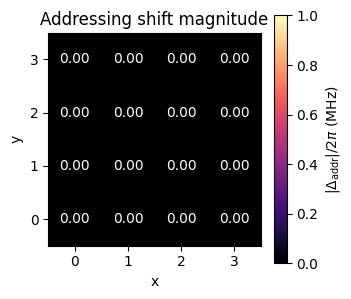

In [6]:
# No local-addressing detuning shift for this run.
Lx= 4
Ly= 4
N_sites = Lx * Ly

# Experimental-style parameters
a_um = 10                         # lattice spacing, um
C6_70s = 2 * np.pi * 874e9         # rad/s * um^6, Rb 70S typical

local_detuning_offsets = np.zeros(N_sites)
# 1. 几何 + 能级结构：3x3 方格，每个格点是 |1>(基态) / |r>(Rydberg) 两能级
geom = make_square_lattice(Lx, Ly, spacing_um=a_um)


Omega = 2 * np.pi * 3.8e6          # rad/s
delta_start = -2 * np.pi * 10.0e6   # rad/s
delta_end = 2 * np.pi * 10.0e6      # rad/s
t_sweep = 1.5e-6                   # s
omega_ramp_frac = 0.1

# Effectively global Rabi
def omega_half_t(t):
    ramp_frac = 0.09
    s = np.clip(t / max(t_sweep, np.finfo(float).eps), 0.0, 1.0)

    def smoothstep5(u):
        u = np.clip(u, 0.0, 1.0)
        return 10.0 * u**3 - 15.0 * u**4 + 6.0 * u**5

    if s < ramp_frac:
        env = smoothstep5(s / ramp_frac)
    elif s > 1.0 - ramp_frac:
        env = smoothstep5((1.0 - s) / ramp_frac)
    else:
        env = 1.0

    return 0.5 * Omega * env

# 全局 Rydberg 失谐：平滑往返扫频 -10 MHz -> +10 MHz -> -10 MHz
def delta_t(t):
    s = np.clip(t / max(t_sweep, np.finfo(float).eps), 0.0, 1.0)
    delta_mid = 0.5 * (delta_start + delta_end)
    delta_amp = 0.5 * (delta_end - delta_start)
    return delta_mid - delta_amp * np.cos(2.0 * np.pi * s)

# 局部 addressing shift；这里全部为 0
def delta_local(t, ind):
    return local_detuning_offsets[ind]

# 2. 自定义 sweep：global Delta(t) 和 local address shift 分开输入
protocol = rg.SweepProtocol(
    t_gate=t_sweep,
    omega_half_fn=omega_half_t,
    delta_fn=delta_t,
    address_fn=delta_local,
    n_steps=120,
)
system = rg.RydbergSystem.from_lattice(
    geom, "1r",
    interaction=InteractionSpec(C6=C6_70s, mode="nn"),       # 近邻 VdW；TN 勿用默认 all
    protocol=protocol,
)
params = system.unpack_params([])
t_eval = np.linspace(0.0, t_sweep, 7)

protocol.plot(system=system, params=params, savefig=False)

# 设置 TN 时间步长
dt_tn = 0.2 / Omega  # seconds; 0.2 * Omega^{-1}, same time unit as t_sweep/t_eval


## 3. Exact state-vector baseline

下面两个 block 使用 `backend="exact"`。

- exact 后端直接保存每个 `t_eval` 的态矢量，每段对完整$H$做精确矩阵指数，无 Trotter 误差
- 仅有认定 $H(t)$ 在段内常数的离散误差
- 平均 Rydberg occupation 和逐格点 occupation 都用 `system.expectation(...)` 从态矢量读出。这个结果作为后面所有近似后端的数值基准。


In [8]:
# 3a. 精确后端：states 是态矢量，用 system.expectation 读 Rydberg 均值和逐格点 occupation。
method = "exact"
_t0 = time.perf_counter()
res = rg.simulate(system, [], "all_ground", backend="exact", t_eval=t_eval)
exact_elapsed = time.perf_counter() - _t0

exact_n_mean = np.asarray([
    system.expectation("sum_nr", psi) / system.N
    for psi in res.states
])
exact_n_i = np.asarray([
    [system.expectation(f"n_r_{i}", psi) for i in range(system.N)]
    for psi in res.states
])

print(f"Exact elapsed: {exact_elapsed:.3f} s")
print("time(us)  exact <n_r>")
for t, exact_val in zip(res.times * 1e6, exact_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}")


Exact elapsed: 44.903 s
time(us)  exact <n_r>
  0.000       0.0000
  0.250       0.1081
  0.500       0.8432
  0.750       0.9609
  1.000       0.8285
  1.250       0.1152
  1.500       0.0024


作图

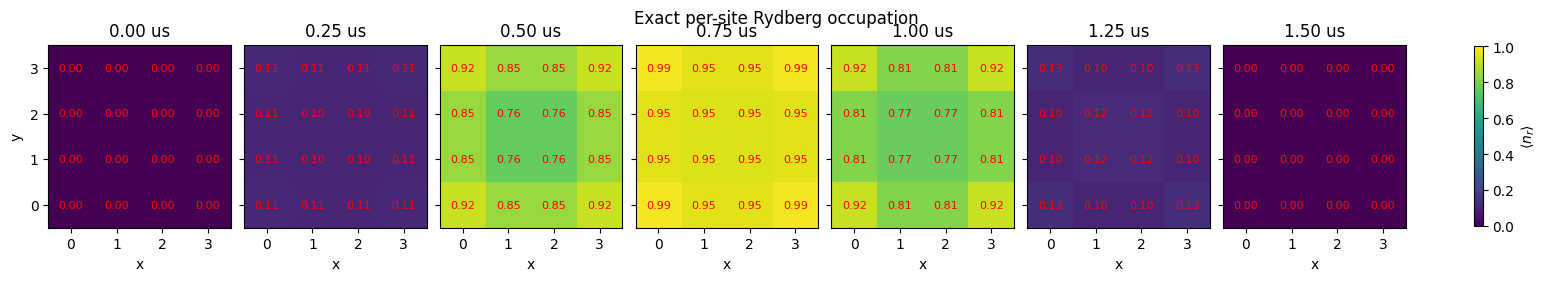

In [13]:
# 3b. 每个时刻的 3x3 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
if exact_n_i is None:
    print("exact has no successful data to plot.")
else:
    fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
    axes_h = np.atleast_1d(axes_h)

    for ax_h, t, occ in zip(axes_h, res.times, exact_n_i):
        grid = occ.reshape(Lx, Ly)
        im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax_h.set_title(f"{t * 1e6:.2f} us")
        ax_h.set_xticks(range(Lx))
        ax_h.set_yticks(range(Ly))
        ax_h.set_xlabel("x")
        if ax_h is axes_h[0]:
            ax_h.set_ylabel("y")
        else:
            ax_h.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                val = grid[ix, iy]
                txt_color = "red"
                ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

    fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
    fig_h.suptitle("Exact per-site Rydberg occupation", y=1.05)
    plt.show()


## 4. TeNPy CPU MPS-TDVP (`mps`)

下面两个 block 使用 `backend="mps"`。它把 3×3 二维晶格按 snake ordering 拉平成一维 MPS，然后用 TeNPy TDVP 做时间演化。主要参数是 `chi_max` 和 `dt`；这里所有 interaction 来自前面的 `system`，也就是最近邻 `nn` pair list。


In [ ]:
# 4a. TeNPy MPS-TDVP (`backend="mps"`)：TN 后端把 <n_r> 和每个格点 <n_i> 记录在 metadata["obs"] 里。
method = "mps"
# 开始计时
_t0 = time.perf_counter()
#开始模拟
res_tenpy = rg.simulate(
    system, [], "all_ground",
    backend="mps", t_eval=t_eval, observables=["n_mean", "n_i"],
    backend_options={"chi_max": 32, "dt": dt_tn, "svd_min": 1e-10},
)
# 计时结束
tenpy_elapsed = time.perf_counter() - _t0
# 读取结果
tenpy_n_mean = np.asarray(res_tenpy.metadata["obs"]["n_mean"])
tenpy_n_i = np.asarray(res_tenpy.metadata["obs"]["n_i"])
# 计算误差
tenpy_diff_mean = float(np.max(np.abs(tenpy_n_mean - exact_n_mean))) if "exact_n_mean" in globals() else np.nan
tenpy_diff_i = float(np.max(np.abs(tenpy_n_i - exact_n_i))) if "exact_n_i" in globals() else np.nan

print(f"TeNPy elapsed: {tenpy_elapsed:.3f} s")
print("time(us)  exact <n_r>  TeNPy <n_r>")
for t, exact_val, tn_val in zip(t_eval * 1e6, exact_n_mean, tenpy_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}  {tn_val:10.4f}")
print(f"max |delta <n_r>| = {tenpy_diff_mean:.3e}; max |delta <n_i>| = {tenpy_diff_i:.3e}")



/home/chance/Ryd-gate-modeling/.venv/lib/python3.10/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


TeNPy elapsed: 297.922 s
time(us)  exact <n_r>  TeNPy <n_r>
  0.000       0.0000      0.0000
  0.250       0.1081      0.1084
  0.500       0.8432      0.8429
  0.750       0.9609      0.9610
  1.000       0.8285      0.8287
  1.250       0.1152      0.1152
  1.500       0.0024      0.0024
max |delta <n_r>| = 2.416e-04; max |delta <n_i>| = 4.966e-04


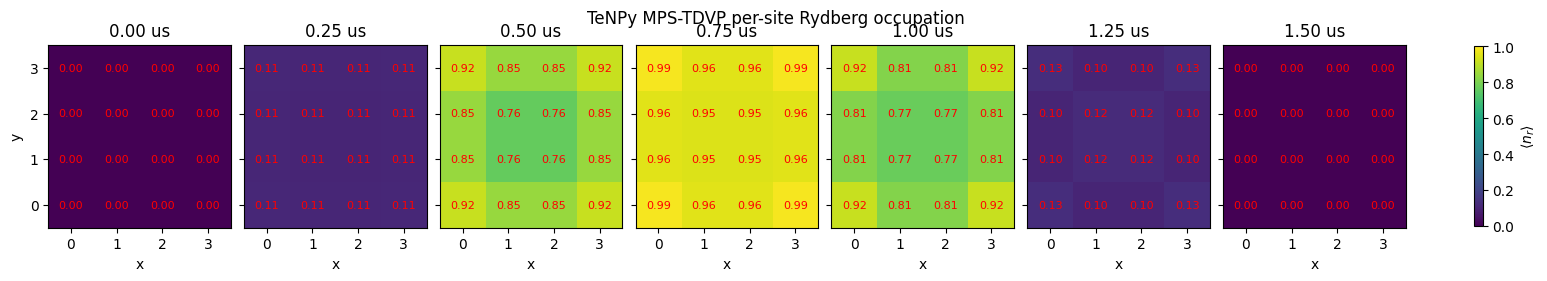

In [15]:
# 4b. 每个时刻的 3x3 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
if tenpy_n_i is None:
    print("mps has no successful data to plot.")
else:
    fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
    axes_h = np.atleast_1d(axes_h)

    for ax_h, t, occ in zip(axes_h, res_tenpy.times, tenpy_n_i):
        grid = occ.reshape(Lx, Ly)
        im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax_h.set_title(f"{t * 1e6:.2f} us")
        ax_h.set_xticks(range(Lx))
        ax_h.set_yticks(range(Ly))
        ax_h.set_xlabel("x")
        if ax_h is axes_h[0]:
            ax_h.set_ylabel("y")
        else:
            ax_h.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                val = grid[ix, iy]
                txt_color = "red"
                ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

    fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
    fig_h.suptitle("TeNPy MPS-TDVP per-site Rydberg occupation", y=1.05)
    plt.show()


## 5. cuTensorNet / CuPy GPUTN (`gputn`)

下面两个 block 使用 `backend="gputn"`。它需要 CuPy、cuQuantum 和可见 NVIDIA GPU。这个 block 保持和其它 TN 一样的 `system` 最近邻 interaction；如果本机缺 CUDA 依赖，会把失败原因写进 benchmark 表，不中断后续 block。


In [ ]:
# 5a. cuTensorNet/CuPy GPUTN：真正 CUDA tensor-network kernel，可用时计入同一 benchmark。
method = "gputn"
# 开始计时
_t0 = time.perf_counter()
# 模拟
res_gputn = rg.simulate(
    system, [], "all_ground",
    backend="gputn", t_eval=t_eval, observables=["n_mean", "n_i"],
    backend_options={"chi_max": 32, "dt": dt_tn, "svd_min": 1e-10, "require_gpu": True, "kernel": "statevector"},
)
# 计时结束
gputn_elapsed = time.perf_counter() - _t0
# 读取结果
gputn_n_mean = np.asarray(res_gputn.metadata["obs"]["n_mean"])
gputn_n_i = np.asarray(res_gputn.metadata["obs"]["n_i"])
# 计算误差
gputn_diff_mean = float(np.max(np.abs(gputn_n_mean - exact_n_mean))) if "exact_n_mean" in globals() else np.nan
gputn_diff_i = float(np.max(np.abs(gputn_n_i - exact_n_i))) if "exact_n_i" in globals() else np.nan

print(f"GPUTN elapsed: {gputn_elapsed:.3f} s")
print("time(us)  exact <n_r>  GPUTN <n_r>")
for t, exact_val, gpu_val in zip(t_eval * 1e6, exact_n_mean, gputn_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}  {gpu_val:10.4f}")
print(f"max |delta <n_r>| = {gputn_diff_mean:.3e}; max |delta <n_i>| = {gputn_diff_i:.3e}")


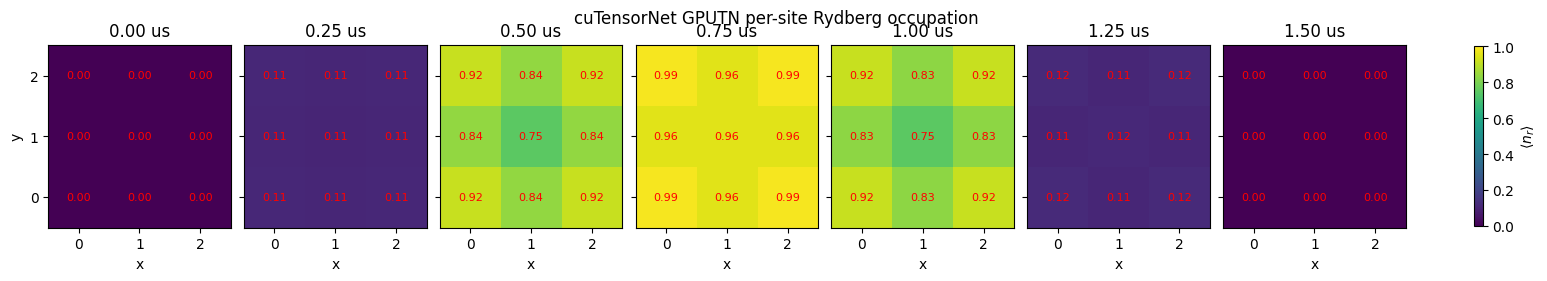

In [ ]:
# 5b. 每个时刻的 3x3 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
axes_h = np.atleast_1d(axes_h)

for ax_h, t, occ in zip(axes_h, res_gputn.times, gputn_n_i):
    grid = occ.reshape(Lx, Ly)
    im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
    ax_h.set_title(f"{t * 1e6:.2f} us")
    ax_h.set_xticks(range(Lx))
    ax_h.set_yticks(range(Ly))
    ax_h.set_xlabel("x")
    if ax_h is axes_h[0]:
        ax_h.set_ylabel("y")
    else:
        ax_h.set_yticklabels([])
    for ix in range(Lx):
        for iy in range(Ly):
            val = grid[ix, iy]
            txt_color = "red"
            ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
fig_h.suptitle("cuTensorNet GPUTN per-site Rydberg occupation", y=1.05)
plt.show()


## 6. YASTN finite-PEPS (`peps`)

下面两个 block 使用 `backend="peps"`。这是 YASTN finite-PEPS 路径，直接保留二维方格几何；默认用 NTU 更新和 BP measurement。设置 `use_cuda=True, yastn_backend="torch", device="cuda"` 后可走 YASTN 的 GPU backend。


In [7]:
# 6a. YASTN finite-PEPS：二维 PEPS 主路径。
method = "peps"
# 开始计时
_t0 = time.perf_counter()

res_peps = rg.simulate(
    system, [], "all_ground",
    backend="peps", t_eval=t_eval, observables=["n_mean", "n_i"],
    backend_options={
        "chi_max": 10,
        "dt": dt_tn,
        "svd_min": 1e-8,
        "measurement_environment": "bp",
        "update_environment": "ntu",
        "max_iter": 10,
        "use_cuda": True,
        "yastn_backend": "torch",
        "device": "cuda",
    },
)
# 计时结束
peps_elapsed = time.perf_counter() - _t0
# 读取结果
peps_n_mean = np.asarray(res_peps.metadata["obs"]["n_mean"])
peps_n_i = np.asarray(res_peps.metadata["obs"]["n_i"])
# 计算误差
peps_diff_mean = float(np.max(np.abs(peps_n_mean - exact_n_mean))) if "exact_n_mean" in globals() else np.nan
peps_diff_i = float(np.max(np.abs(peps_n_i - exact_n_i))) if "exact_n_i" in globals() else np.nan
print(f"PEPS elapsed: {peps_elapsed:.3f} s")
print("time(us)  exact <n_r>  PEPS <n_r>")
for t, exact_val, p_val in zip(t_eval * 1e6, exact_n_mean, peps_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}  {p_val:10.4f}")
print(f"max |delta <n_r>| = {peps_diff_mean:.3e}; max |delta <n_i>| = {peps_diff_i:.3e}")



PEPS elapsed: 722.760 s
time(us)  exact <n_r>  PEPS <n_r>


NameError: name 'exact_n_mean' is not defined

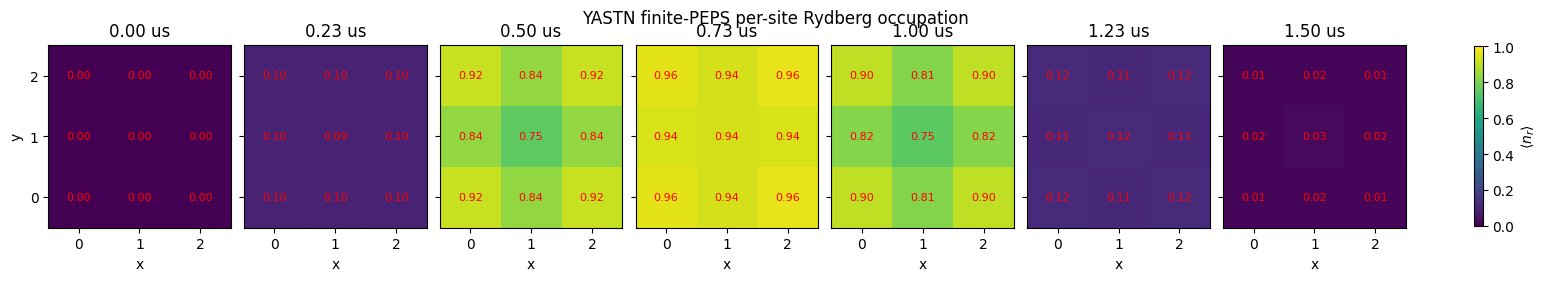

In [ ]:
# 6b. 每个时刻的 3x3 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。

fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
axes_h = np.atleast_1d(axes_h)

for ax_h, t, occ in zip(axes_h, res_peps.times, peps_n_i):
    grid = occ.reshape(Lx, Ly)
    im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
    ax_h.set_title(f"{t * 1e6:.2f} us")
    ax_h.set_xticks(range(Lx))
    ax_h.set_yticks(range(Ly))
    ax_h.set_xlabel("x")
    if ax_h is axes_h[0]:
        ax_h.set_ylabel("y")
    else:
        ax_h.set_yticklabels([])
    for ix in range(Lx):
        for iy in range(Ly):
            val = grid[ix, iy]
            txt_color = "red"
            ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
fig_h.suptitle("YASTN finite-PEPS per-site Rydberg occupation", y=1.05)
plt.show()
